In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as si


In [7]:
# Option parameters
S = 100      # Current stock price
K = 100      # Strike price
T = 1        # Time to maturity (1 year)
r = 0.05     # Risk free interest rate
sigma = 0.2  # Volatility

In [8]:
# call option price using Black-Scholes formula
def black_scholes_call(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    call = S * si.norm.cdf(d1) - K * np.exp(-r*T) * si.norm.cdf(d2)

    return call

In [9]:
# put option price using Black-Scholes formula
def black_scholes_put(S, K, T, r, sigma):

    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    put = K * np.exp(-r*T) * si.norm.cdf(-d2) - S * si.norm.cdf(-d1)

    return put

In [10]:
call_price = black_scholes_call(S, K, T, r, sigma)
put_price = black_scholes_put(S, K, T, r, sigma)

print("Call Option Price:", call_price)
print("Put Option Price:", put_price)

Call Option Price: 10.450583572185565
Put Option Price: 5.573526022256971


In [11]:
# delta
def delta_call(S,K,T,r,sigma):

    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))

    return si.norm.cdf(d1)

In [12]:
# gamma
def gamma(S,K,T,r,sigma):

    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))

    return si.norm.pdf(d1)/(S*sigma*np.sqrt(T))

In [13]:
# vega
def vega(S,K,T,r,sigma):

    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))

    return S * si.norm.pdf(d1) * np.sqrt(T)

In [14]:
# theta
def theta_call(S,K,T,r,sigma):

    d1 = (np.log(S/K)+(r+sigma**2/2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    term1 = -(S * si.norm.pdf(d1) * sigma) / (2*np.sqrt(T))
    term2 = -r * K * np.exp(-r*T) * si.norm.cdf(d2)

    return term1 + term2

In [15]:
print("Delta:", delta_call(S,K,T,r,sigma))
print("Gamma:", gamma(S,K,T,r,sigma))
print("Vega:", vega(S,K,T,r,sigma))
print("Theta:", theta_call(S,K,T,r,sigma))

Delta: 0.6368306511756191
Gamma: 0.018762017345846895
Vega: 37.52403469169379
Theta: -6.414027546438197


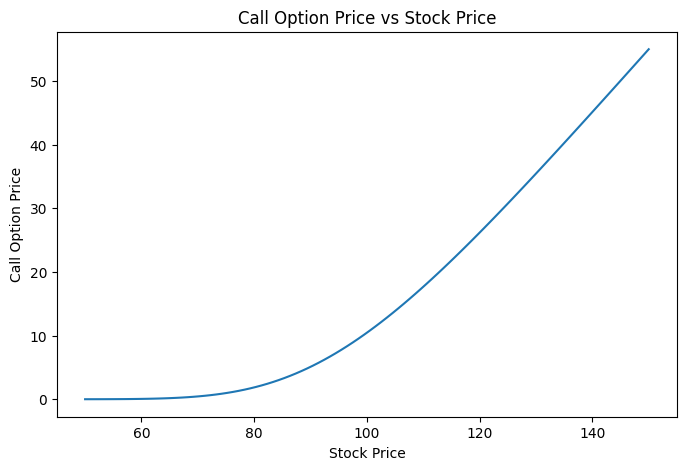

In [16]:
stock_prices = np.linspace(50,150,100)

call_prices = [black_scholes_call(S,K,T,r,sigma) for S in stock_prices]

plt.figure(figsize=(8,5))
plt.plot(stock_prices,call_prices)

plt.xlabel("Stock Price")
plt.ylabel("Call Option Price")
plt.title("Call Option Price vs Stock Price")

plt.show()

In [17]:
S0 = 100
T = 1
r = 0.05
sigma = 0.2

simulations = 1000
steps = 252

dt = T/steps

prices = np.zeros((steps,simulations))

prices[0] = S0

for t in range(1,steps):

    Z = np.random.standard_normal(simulations)

    prices[t] = prices[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z)

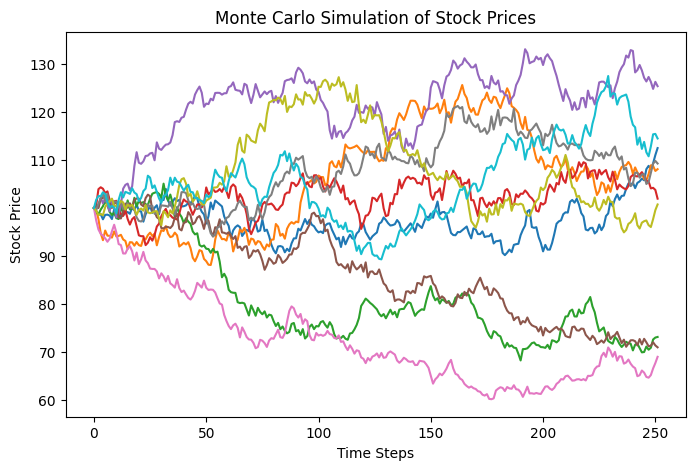

In [18]:
plt.figure(figsize=(8,5))

plt.plot(prices[:,:10])

plt.title("Monte Carlo Simulation of Stock Prices")

plt.xlabel("Time Steps")
plt.ylabel("Stock Price")

plt.show()

In [19]:
payoff = np.maximum(prices[-1] - K,0)

mc_price = np.exp(-r*T) * np.mean(payoff)

print("Monte Carlo Call Price:", mc_price)

Monte Carlo Call Price: 10.393514688141961


In [20]:
print("Black Scholes Call Price:", call_price)
print("Monte Carlo Call Price:", mc_price)

Black Scholes Call Price: 10.450583572185565
Monte Carlo Call Price: 10.393514688141961
